### Coding Question: Image Classification Neural Network

Using the dataset provided below, design and implement a **Neural Network for multi-class image classification**.

**Dataset:** [Nepali Numbers and Letters Dataset](https://github.com/ShaileshAdhikari/nepali-text-classification/blob/main/images.rar)

Your implementation should include:

1. **Data Preparation**

   * Load, preprocess, resize, normalize, and split the dataset into train/validation/test sets.

2. **Neural Network**

3. **Hyperparameter Tuning**

4. **Evaluation**
   Evaluate the final model using:

   * Accuracy
   * Precision
   * Recall
   * F1-score
   * Macro/Weighted F1
   * Confusion Matrix

5. **Performance Analysis**

**Deliverable:** Complete, reproducible code with a final report comparing the experimented configurations and their performance.


# Nepali Plate Character Classification

Multi-class image classification of Nepali license-plate characters (digits `0`-`9` and the letters `ba`, `pa`) using neural networks. The notebook compares a dense network (ANN) with a convolutional network (CNN), tunes the CNN, and evaluates the final model on an unseen test set.

## 1. Data Preparation
Load the images, explore them, then preprocess (grayscale, resize, normalize) and split into train / validation / test sets.

In [1]:
#  Solution
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

### 1.1 Load the dataset
Walk through the extracted `images/` folder. The **folder name is the class label**. For each image we store its path, label, size and color mode in a table (`df`).

In [2]:
DATA_DIR = "images"   # folder created by extracting images.rar
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp")

print("Working directory:", os.getcwd())
print("Folder exists:", os.path.isdir(DATA_DIR))

rows = []
for root, dirs, files in os.walk(DATA_DIR):
    for fname in files:
        if fname.lower().endswith(IMG_EXT):
            path = os.path.join(root, fname)
            try:
                with Image.open(path) as im:
                    w, h = im.size
                    rows.append({"path": path,
                                 "label": os.path.basename(root),  # folder name = class
                                 "width": w, "height": h, "mode": im.mode})
            except Exception as e:
                print("Skipping", path, e)

Working directory: c:\Users\shahh\OneDrive\Desktop\Data Science And Machine Learning\Skill_Sikshya\Day57
Folder exists: True


### 1.2 Explore the data
Check the number of images, the images per class, the image sizes and the color mode. The images have many different sizes and are RGB, so they will need to be resized to one common shape.

In [3]:
df = pd.DataFrame(rows)
print("Total images:", df.shape[0])
print(df["label"].value_counts().sort_index())
print(df[["width", "height"]].describe())
print(df["mode"].value_counts())

Total images: 2033
label
0      96
1     171
2     176
3     186
4     206
5     194
6     159
7     147
8     135
9     123
ba    206
pa    234
Name: count, dtype: int64
             width       height
count  2033.000000  2033.000000
mean    104.484998   132.072307
std     216.917001   340.992631
min      14.000000    15.000000
25%      45.000000    53.000000
50%      66.000000    78.000000
75%      96.000000   107.000000
max    1936.000000  3104.000000
mode
RGB    2033
Name: count, dtype: int64


In [4]:
df.head()

,path,label,width,height,mode
0,images\0\1.jpg,0,85,94,RGB
1,images\0\10.jpg,0,107,100,RGB
2,images\0\11.jpg,0,78,104,RGB
3,images\0\12.jpg,0,59,78,RGB
4,images\0\13.jpg,0,34,40,RGB


In [5]:
df["label"].value_counts().sum()

np.int64(2033)

In [6]:
df["width"].value_counts().sum()

np.int64(2033)

In [7]:
df["height"].value_counts().sum()

np.int64(2033)

#### Class balance and sample images
The bar chart checks whether the classes are balanced. The grid shows 5 random images per class to see what the data looks like.

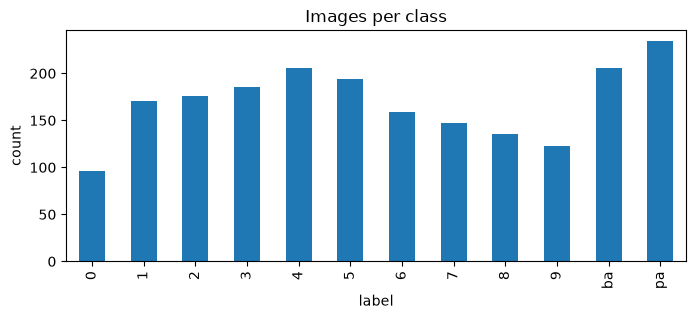

In [8]:
#plot to check imbalance

df["label"].value_counts().sort_index().plot(
    kind = "bar",
    figsize = (8, 3),
    title = "Images per class"
    
)
plt.ylabel("count")
plt.show()

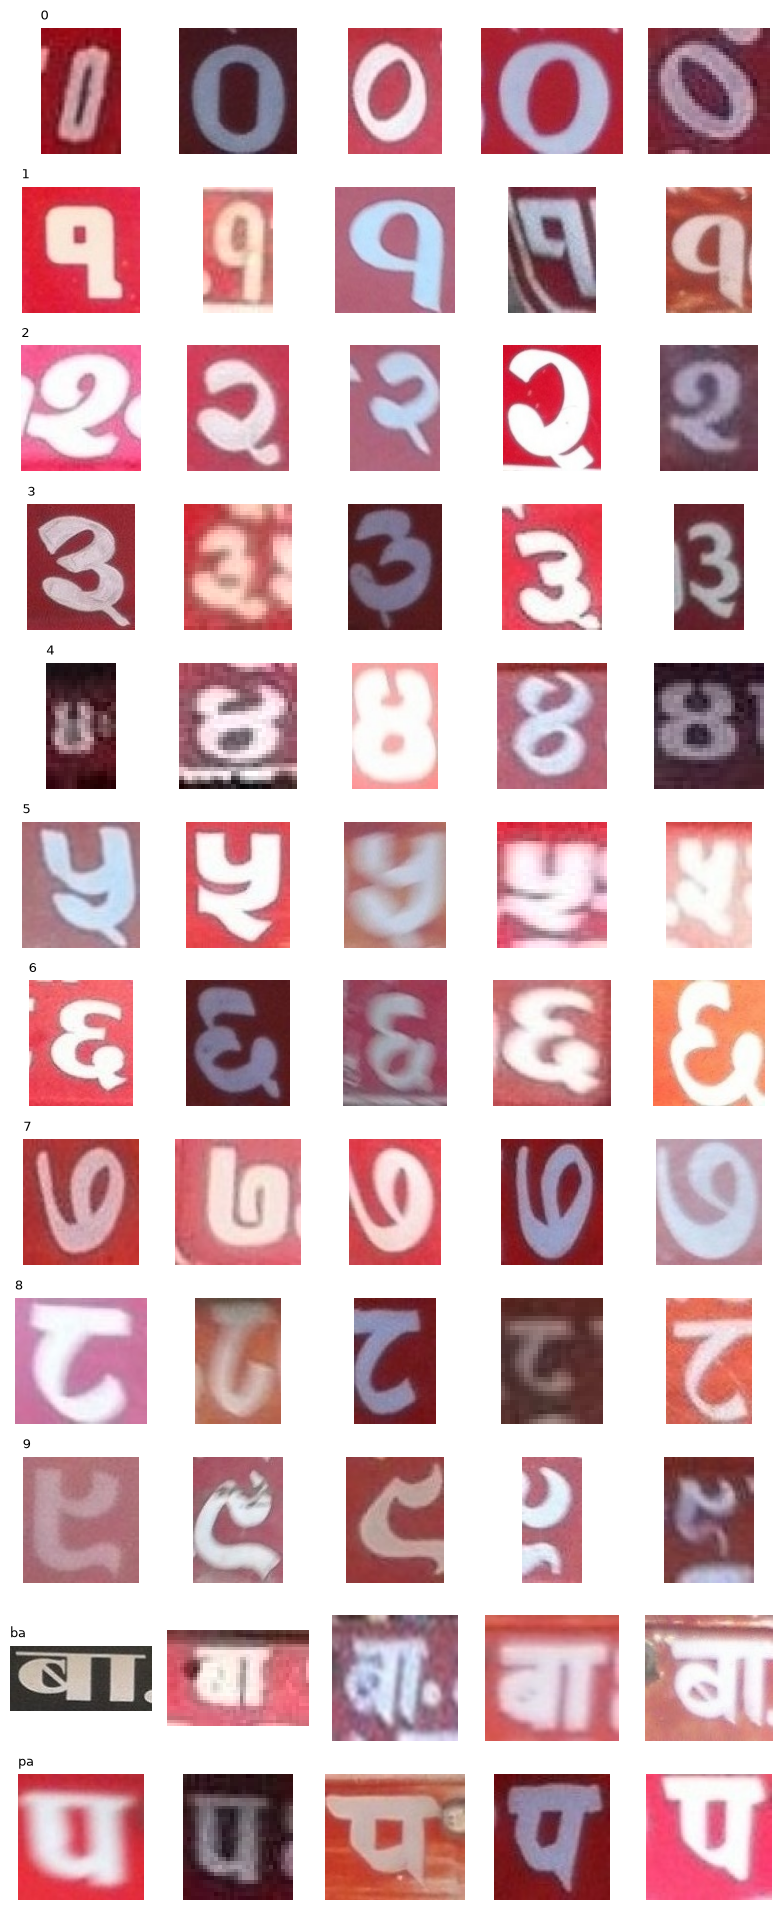

In [9]:
# checking 5 sample images to check whether the images are hadwritten, backgorund is cluttered or any image is wrong
classes = sorted(df["label"].unique())
fig, axes = plt.subplots(len(classes), 5, figsize=(8, 1.6 * len(classes)))
for i,c in enumerate(classes):
    samples = df[df["label"] == c].sample(5, random_state = 42)
    for j, path in enumerate(samples["path"]):
        axes[i, j].imshow(Image.open(path))
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_title(c, loc="left", fontsize=9)
plt.tight_layout()
plt.show()

**Observations from the exploration**
- 2,033 images in 12 classes, with an imbalance (from 96 images for class `0` to 234 for class `pa`). This is handled later with a stratified split, class weights and macro F1.
- The images are cropped license-plate characters, mostly on red backgrounds, and many are blurry, tilted or unevenly lit.
- Image sizes vary a lot, so they must be resized.

### 1.3 Preprocessing
- Convert to **grayscale** (the red background carries no information about the character).
- **Resize to 32x32** so every image has the same shape.
- **Normalize** pixel values to the range 0-1 by dividing by 255.

In [10]:
# Pre-Processing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

IMG_SIZE = 32
SEED = 42

def load_image(path):
    with Image.open(path) as im:
        im = im.convert("L").resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
        return np.asarray(im, dtype = "float32") / 255.0
    
X = np.stack([load_image(p) for p in df["path"]])
X = X[..., np.newaxis]

In [11]:
# labels : conveting from text to integers which neural networks understands

le = LabelEncoder()
y = le.fit_transform(df["label"])
class_names = le.classes_
print("classes:", class_names)
print("X shape:", X.shape, "y shape:", y.shape)

classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'ba' 'pa']
X shape: (2033, 32, 32, 1) y shape: (2033,)


### 1.4 Train / validation / test split
A stratified **70 / 15 / 15** split keeps the class proportions the same in every set. The model learns from the training set, the validation set is used to compare models and settings, and the test set is used only once at the end. The random seed (42) makes the split reproducible. The targets are then one-hot encoded (fitted on the training labels only).

In [12]:
# splitting the data into train , validation and test

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size = 0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
)

In [13]:
# one hot encode the targets --- fit on train only

ohe = OneHotEncoder(sparse_output=False)
y_train_enc = ohe.fit_transform(y_train.reshape(-1,1))
y_val_enc = ohe.transform(y_val.reshape(-1, 1))
y_test_enc = ohe.transform(y_test.reshape(-1,1))


print("Train:", X_train.shape, y_train_enc.shape)
print("Val:", X_val.shape, y_val_enc.shape)
print("Test:", X_test.shape, y_test_enc.shape)

Train: (1423, 32, 32, 1) (1423, 12)
Val: (305, 32, 32, 1) (305, 12)
Test: (305, 32, 32, 1) (305, 12)


In [14]:
# checking the class proportions in each class

split_counts = pd.DataFrame({
    "train": pd.Series(y_train).value_counts(normalize=True).sort_index(),
    "val": pd.Series(y_val).value_counts(normalize=True).sort_index(),
    "test": pd.Series(y_test).value_counts(normalize=True).sort_index()
})
split_counts.index = class_names
print(split_counts.round(3))

    train    val   test
0   0.047  0.046  0.049
1   0.084  0.085  0.082
2   0.086  0.085  0.089
3   0.091  0.092  0.092
4   0.101  0.102  0.102
5   0.096  0.095  0.095
6   0.078  0.079  0.079
7   0.072  0.072  0.072
8   0.067  0.066  0.066
9   0.060  0.062  0.059
ba  0.101  0.102  0.102
pa  0.115  0.115  0.115


What model will actually see?

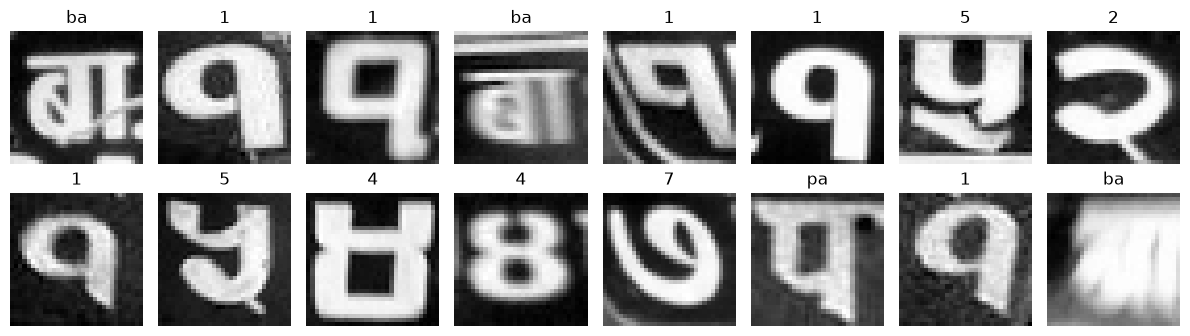

In [15]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for ax, i in zip(axes.ravel(), np.random.RandomState(0).choice(len(X_train), 16, replace=False)):
    ax.imshow(X_train[i].squeeze(), cmap="gray")
    ax.set_title(class_names[y_train[i]])
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Neural Network

### 2.1 Baseline ANN (dense network)
A simple fully connected network used as a baseline: the image is flattened, passed through two hidden layers (256 and 128 neurons) with dropout, and a 12-class softmax output.

- **Class weights** give more importance to the smaller classes to handle the imbalance.
- **Early stopping** ends training when the validation loss stops improving and restores the best weights.

In [16]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

In [17]:
tf.keras.utils.set_random_seed(SEED)

# class weigths to  handle imbalance

w = compute_class_weight("balanced", classes = np.unique(y_train), y=y_train)
class_weight = dict(enumerate(w))

ann = Sequential([
    Input(shape = (32,32,1)),
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(12, activation= "softmax")
])
ann.compile(optimizer= "adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [18]:
history = ann.fit(
    X_train, y_train_enc,
    validation_data = (X_val, y_val_enc),
    epochs=100, batch_size=32,
    class_weight= class_weight,
    callbacks=[EarlyStopping(monitor = "val_loss", patience=10, restore_best_weights=True )]
)

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0998 - loss: 2.5590 - val_accuracy: 0.1607 - val_loss: 2.4544
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1216 - loss: 2.4525 - val_accuracy: 0.3213 - val_loss: 2.3611
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1897 - loss: 2.3596 - val_accuracy: 0.4426 - val_loss: 2.2093
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2600 - loss: 2.2065 - val_accuracy: 0.4033 - val_loss: 2.0558
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2860 - loss: 2.0769 - val_accuracy: 0.4656 - val_loss: 1.8728
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3486 - loss: 1.8856 - val_accuracy: 0.5344 - val_loss: 1.6839
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3703 - loss: 1.8049 - val_accuracy: 0.5705 - val_loss: 1.5864
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4266 - loss: 1.6893 - val_accuracy: 0.6426 - 

In [19]:
from sklearn.metrics import f1_score

val_pred = np.argmax(ann.predict(X_val), axis =1)
val_acc = (val_pred == y_val).mean()
val_f1 = f1_score(y_val, val_pred, average = "macro")
print(f"Validation accuracy: {val_acc:.4f}")
print(f"Macro F1: {val_f1:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Validation accuracy: 0.8066
Macro F1: 0.8092


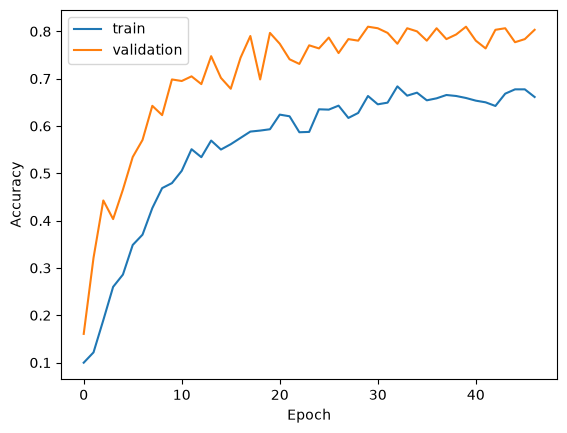

In [20]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.show()



In [21]:
results = [{"model": "ANN baseline", "val_acc": val_acc, "val_macro_f1": val_f1}]

**ANN result:** validation accuracy 0.8066, macro F1 0.8092.

### 2.2 Baseline CNN
A convolutional network can detect strokes and curves wherever they appear in the image, which suits character images better than a flattened dense network. Architecture: two convolution + max-pooling blocks (32 and 64 filters), then a dense layer with dropout and a 12-class softmax.

*Note:* in this baseline the second `Conv2D` layer has no ReLU activation, so it is a linear layer. The tuned CNNs in Section 3 use ReLU in both convolution layers, so part of their improvement over this baseline may come from that change as well as from the tuned settings.

In [22]:
# CNN

from tensorflow.keras.layers import Conv2D, MaxPooling2D

tf.keras.utils.set_random_seed(SEED)

cnn = Sequential([
    Input(shape=(32,32,1)),
    Conv2D(32, (3,3), activation="relu", padding="same"),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(12, activation="softmax")
])
cnn.compile(optimizer="adam", loss="categorical_crossentropy",  metrics=["accuracy"])

In [23]:
histroy_cnn = cnn.fit(
    X_train, y_train_enc,
    validation_data=(X_val, y_val_enc),
    epochs = 100,
    batch_size = 32,
    class_weight = class_weight,
    callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)]
)

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.1602 - loss: 2.4399 - val_accuracy: 0.3967 - val_loss: 2.2497
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4884 - loss: 1.7444 - val_accuracy: 0.7574 - val_loss: 0.9899
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7280 - loss: 0.9173 - val_accuracy: 0.8033 - val_loss: 0.6974
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8067 - loss: 0.6323 - val_accuracy: 0.8557 - val_loss: 0.5603
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8658 - loss: 0.4681 - val_accuracy: 0.8590 - val_loss: 0.4762
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8897 - loss: 0.3774 - val_accuracy: 0.8754 - val_loss: 0.4375
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9164 - loss: 0.2968 - val_accuracy: 0.9016 - val_loss: 0.3920
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9339 - loss: 0.2301 - val_accuracy: 0.

In [24]:
val_pred = np.argmax(cnn.predict(X_val), axis =1)
val_acc = (val_pred == y_val).mean()
val_f1 = f1_score(y_val, val_pred, average = "macro")

print(f"Validation accuracy: {val_acc:.4f}")
print(f"Macro F1: {val_f1:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Validation accuracy: 0.9016
Macro F1: 0.8991


**CNN baseline result:** validation accuracy 0.9016, macro F1 0.8991, about 9.5 points above the ANN baseline.

## 3. Hyperparameter Tuning
The CNN is rebuilt with a function whose key settings can be changed (learning rate, dropout, dense layer size). Every experiment uses the same seed, class weights, early stopping and the same validation set, so the results are comparable. All results are collected in the `results` list.

In [25]:
# Hyper Parameter Tuning

def build_cnn(lr=1e-3,dropout=0.3, dense= 128):
    model = Sequential([
        Input(shape=(32,32,1)),
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(dense, activation="relu"),
        Dropout(dropout),
        Dense(12, activation="softmax")
    ])
    model.compile(optimizer = tf.keras.optimizers.Adam(lr), 
                  loss="categorical_crossentropy", metrics=["accuracy"])
    return model
    

### 3.1 Single-setting experiments
Change one setting at a time and record validation accuracy and macro F1: a lower and a higher learning rate, a higher dropout, and a wider dense layer.

In [26]:
configs = {
    "Cnn lr=3e-4": dict(lr=3e-4),
    "CNN lr=3e-3": dict(lr=3e-3),
    "CNN dropout=0.5": dict(dropout=0.5),
    "CNN dense=256" : dict(dense=256),
}

for name, params in configs.items():
    tf.keras.utils.set_random_seed(SEED)
    m = build_cnn(**params)
    m.fit(X_train, y_train_enc, validation_data=(X_val, y_val_enc),
          epochs=100, batch_size = 32, class_weight=class_weight,
          verbose = 0,
          callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)])
    pred = np.argmax(m.predict(X_val, verbose=0), axis=1)
    results.append({
        "model": name, 
        "val_acc": (pred == y_val).mean(),
        "val_macro_f1": f1_score(y_val, pred, average = "macro")
    })
    
pd.DataFrame(results).sort_values("val_macro_f1", ascending=False)
    

,model,val_acc,val_macro_f1
3,CNN dropout=0.5,0.937705,0.936219
1,Cnn lr=3e-4,0.934426,0.934109
4,CNN dense=256,0.914754,0.914514
2,CNN lr=3e-3,0.904918,0.904262
0,ANN baseline,0.806557,0.809171


### 3.2 Clean up the results table
Because some cells were run more than once, the table contained duplicate and mislabeled rows. These cells fix the model names, remove duplicates and add the CNN baseline result (0.9016 / 0.8991) so that each experiment appears once.

In [27]:
res = pd.DataFrame(results)
res["model"] = res["model"].replace("Cnn lr=3e-4", "CNN lr=3e-4")
res = res[res["model"] != "CNN baseline"].drop_duplicates("model")
res = pd.concat([res, pd.DataFrame([{"model": "CNN baseline",
                                     "val_acc": 0.9016, "val_macro_f1": 0.8991}])],
                ignore_index=True)
results = res.to_dict("records")
res.sort_values("val_macro_f1", ascending=False)

,model,val_acc,val_macro_f1
3,CNN dropout=0.5,0.937705,0.936219
1,CNN lr=3e-4,0.934426,0.934109
4,CNN dense=256,0.914754,0.914514
2,CNN lr=3e-3,0.904918,0.904262
5,CNN baseline,0.901600,0.899100
0,ANN baseline,0.806557,0.809171


In [28]:
results.append({"model": "CNN baseline", "val_acc": 0.9016, "val_macro_f1": 0.8991})

### 3.3 Combined settings and data augmentation
The two best single settings (dropout 0.5 and learning rate 3e-4) are combined, and then data augmentation is added: small random rotations, zooms and shifts applied during training only. Flips are not used because a flipped character can look like a different character. The helper function `train_and_score` trains a model and records its validation scores.

In [29]:
from tensorflow.keras.layers import RandomRotation, RandomZoom, RandomTranslation

def train_and_score(name, model):
    model.fit(X_train, y_train_enc, validation_data=(X_val, y_val_enc),
              epochs=150, batch_size=32, class_weight=class_weight, verbose=0,
              callbacks=[EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)])
    pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    results.append({"model": name, "val_acc": (pred == y_val).mean(),
                    "val_macro_f1": f1_score(y_val, pred, average="macro")})
    return model

In [30]:
tf.keras.utils.set_random_seed(SEED)

cnn_combo = train_and_score("CNN dropout=0.5 + lr=3e-4", build_cnn(lr=3e-4, dropout=0.5))

In [31]:
tf.keras.utils.set_random_seed(SEED)
cnn_aug = Sequential([Input(shape=(32, 32, 1)),
                      RandomRotation(0.08), RandomZoom(0.1), RandomTranslation(0.08, 0.08),
                      build_cnn(lr=3e-4, dropout=0.5)])
cnn_aug.compile(optimizer=tf.keras.optimizers.Adam(3e-4),
                loss="categorical_crossentropy", metrics=["accuracy"])
cnn_aug = train_and_score("CNN dropout=0.5 + lr=3e-4 + augmentation", cnn_aug)

pd.DataFrame(results).sort_values("val_macro_f1", ascending=False)

,model,val_acc,val_macro_f1
8,CNN dropout=0.5 + lr=3e-4 + augmentation,0.973770,0.974593
3,CNN dropout=0.5,0.937705,0.936219
1,CNN lr=3e-4,0.934426,0.934109
7,CNN dropout=0.5 + lr=3e-4,0.931148,0.930317
4,CNN dense=256,0.914754,0.914514
2,CNN lr=3e-3,0.904918,0.904262
6,CNN baseline,0.901600,0.899100
5,CNN baseline,0.901600,0.899100
0,ANN baseline,0.806557,0.809171


**Tuning findings**
- Lower learning rate (3e-4) and higher dropout (0.5) each improved the CNN, and a very high learning rate (3e-3) helped least.
- Combining dropout and a lower learning rate did not improve on either alone. The differences are within noise on a validation set of only 305 images.
- **Data augmentation gave the largest gain** (about 4 points): validation accuracy 0.9738 and macro F1 0.9746. With only 1,423 training images, augmentation acts like extra training data.
- The best configuration is **CNN, dropout 0.5, lr 3e-4, with augmentation**.

The cell below removes any remaining duplicate rows from the results.

In [32]:
results = pd.DataFrame(results).drop_duplicates("model").to_dict("records")

## 4. Evaluation
The final model is evaluated **once** on the unseen test set. The classification report gives accuracy and per-class precision, recall and F1, plus the macro and weighted averages. The confusion matrix shows which characters get mixed up.

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
              precision    recall  f1-score   support

           0      0.938     1.000     0.968        15
           1      1.000     0.960     0.980        25
           2      0.963     0.963     0.963        27
           3      0.933     1.000     0.966        28
           4      0.963     0.839     0.897        31
           5      0.903     0.966     0.933        29
           6      0.885     0.958     0.920        24
           7      0.917     1.000     0.957        22
           8      1.000     0.950     0.974        20
           9      1.000     0.833     0.909        18
          ba      0.969     1.000     0.984        31
          pa      0.971     0.943     0.957        35

    accuracy                          0.951       305
   macro avg      0.953     0.951     0.951       305
weighted avg      0.953     0.951     0.950       305



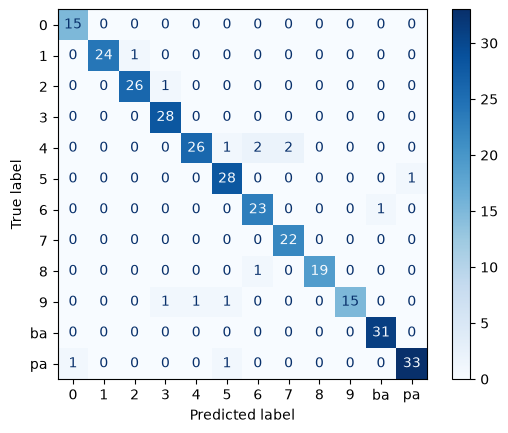

In [33]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
y_pred = np.argmax(cnn_aug.predict(X_test), axis=1)

print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=class_names).plot(cmap="Blues")
plt.show()

**Test-set findings**
- Accuracy 0.951, macro F1 0.951, weighted F1 0.950 (15 errors out of 305 images).
- Macro F1 is equal to accuracy, so the smaller classes are not being neglected.
- The weakest classes are `4` and `9` (recall about 0.84). Some `4` images are predicted as `5`, `6` or `7`, and the `9` images are spread across `3`, `4` and `5`.
- The test score is slightly lower than the validation score (0.974) because the model was chosen using the validation set, so the test score is the more honest estimate.

#### Misclassified examples
The first 10 test images the model got wrong (T = true label, P = predicted label). Most are blurry, cropped, noisy or visually similar to another character.

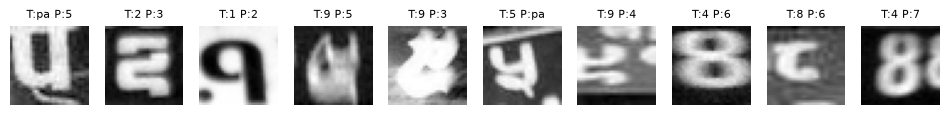

In [34]:
wrong = np.where(y_pred != y_test)[0][:10]
plt.figure(figsize=(12, 3))
for k, i in enumerate(wrong):
    plt.subplot(1, len(wrong), k + 1)
    plt.imshow(X_test[i].squeeze(), cmap="gray")
    plt.title(f"T:{class_names[y_test[i]]} P:{class_names[y_pred[i]]}", fontsize=8)
    plt.axis("off")
plt.show()

## 5. Performance Analysis
The final report below summarizes all experiments, the final test result and what was learned.

## Final Report

**Task:** 12-class classification of Nepali plate characters (digits 0-9, "ba", "pa"), 2,033 images.

**Preprocessing:** grayscale, resized to 32x32, scaled to 0-1, stratified 70/15/15 split (seed 42), class weights for imbalance.

### Validation results of all configurations
| Model | Val accuracy | Val macro F1 |
|---|---|---|
| ANN baseline | 0.8066 | 0.8092 |
| CNN baseline | 0.9016 | 0.8991 |
| CNN lr=3e-3 | 0.9049 | 0.9043 |
| CNN dense=256 | 0.9148 | 0.9145 |
| CNN dropout=0.5 + lr=3e-4 | 0.9311 | 0.9303 |
| CNN lr=3e-4 | 0.9344 | 0.9341 |
| CNN dropout=0.5 | 0.9377 | 0.9362 |
| **CNN dropout=0.5 + lr=3e-4 + augmentation** | **0.9738** | **0.9746** |

### Final model on the unseen test set
Accuracy 0.951, macro F1 0.951, weighted F1 0.950 (305 images, 15 errors).

### Analysis
- CNNs beat the dense ANN by 10+ points, since convolutions capture local stroke patterns regardless of position.
- A lower learning rate and higher dropout each helped, but combining them alone did not (differences are within noise on 305 validation images).
- Data augmentation (small rotations, zooms, shifts) gave the largest gain (~4 points), which is expected with only 1,423 training images.
- Weakest classes were 4 and 9 (recall ~0.84). Most errors are blurry, cropped, or visually similar characters.
- Limitations: small dataset, small validation/test sets (about +/-2.4% uncertainty), and 32x32 resolution may lose detail.
- Possible improvements: larger input size, more augmentation, batch normalization, transfer learning, and cross-validation.

### Save the final model
Save the trained model so it can be reloaded later without retraining.

In [37]:
cnn_aug.save("best_CNN.keras")